In [1]:
import pandas as pd

path_to_file = "/Users/thierrylegros/00-JEDHA/Fullstack-AI/PrepWork"
data = pd.read_excel(path_to_file + "/COVID-19.xlsx")

In [2]:
data.head()


,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,2020-12-14,14,12,2020,746,6,Afghanistan,AF,AFG,38041757.0,Asia,9.013779
1,2020-12-13,13,12,2020,298,9,Afghanistan,AF,AFG,38041757.0,Asia,7.052776
2,2020-12-12,12,12,2020,113,11,Afghanistan,AF,AFG,38041757.0,Asia,6.868768
3,2020-12-11,11,12,2020,63,10,Afghanistan,AF,AFG,38041757.0,Asia,7.134266
4,2020-12-10,10,12,2020,202,16,Afghanistan,AF,AFG,38041757.0,Asia,6.968658


In [ ]:
fr_mask = data["geoId"] == "FR"
fr_data = data[fr_mask]
fr_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
20364,2020-12-14,14,12,2020,11533,150,France,FR,FRA,67012883.0,Europe,236.326200
20365,2020-12-13,13,12,2020,13947,194,France,FR,FRA,67012883.0,Europe,233.716254
20366,2020-12-12,12,12,2020,13406,627,France,FR,FRA,67012883.0,Europe,231.556968
20367,2020-12-11,11,12,2020,13750,292,France,FR,FRA,67012883.0,Europe,230.263187
20368,2020-12-10,10,12,2020,14595,296,France,FR,FRA,67012883.0,Europe,229.984136


In [4]:
fr_data["cumulated-cases"] = 0
fr_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,cumulated-cases
20364,2020-12-14,14,12,2020,11533,150,France,FR,FRA,67012883.0,Europe,236.326200,0
20365,2020-12-13,13,12,2020,13947,194,France,FR,FRA,67012883.0,Europe,233.716254,0
20366,2020-12-12,12,12,2020,13406,627,France,FR,FRA,67012883.0,Europe,231.556968,0
20367,2020-12-11,11,12,2020,13750,292,France,FR,FRA,67012883.0,Europe,230.263187,0
20368,2020-12-10,10,12,2020,14595,296,France,FR,FRA,67012883.0,Europe,229.984136,0


In [5]:
totalrows = len(fr_data)
print(totalrows)


350


In [6]:
totalrows


350

In [9]:
fr_data = fr_data.reset_index(drop=True)

In [10]:
fr_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,cumulated-cases
0,2020-12-14,14,12,2020,11533,150,France,FR,FRA,67012883.0,Europe,236.326200,0
1,2020-12-13,13,12,2020,13947,194,France,FR,FRA,67012883.0,Europe,233.716254,0
2,2020-12-12,12,12,2020,13406,627,France,FR,FRA,67012883.0,Europe,231.556968,0
3,2020-12-11,11,12,2020,13750,292,France,FR,FRA,67012883.0,Europe,230.263187,0
4,2020-12-10,10,12,2020,14595,296,France,FR,FRA,67012883.0,Europe,229.984136,0


In [ ]:
for i in range(totalrows - 2, -1, -1):
    fr_data.iloc[i, fr_data.columns.get_loc("cumulated-cases")] = (
        fr_data.iloc[i, fr_data.columns.get_loc("cases")]
        + fr_data.iloc[i + 1, fr_data.columns.get_loc("cumulated-cases")]
    )

fr_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,cumulated-cases
0,2020-12-14,14,12,2020,11533,150,France,FR,FRA,67012883.0,Europe,236.326200,2376852
1,2020-12-13,13,12,2020,13947,194,France,FR,FRA,67012883.0,Europe,233.716254,2365319
2,2020-12-12,12,12,2020,13406,627,France,FR,FRA,67012883.0,Europe,231.556968,2351372
3,2020-12-11,11,12,2020,13750,292,France,FR,FRA,67012883.0,Europe,230.263187,2337966
4,2020-12-10,10,12,2020,14595,296,France,FR,FRA,67012883.0,Europe,229.984136,2324216


In [ ]:
fr_data.head()


In [ ]:
newcases = 0
for i in range(totalrows - 2, -1, -1):
    fr_data.at[i, "newcases"] = int(fr_data.at[i, "cumulated-cases"]) - int(
        fr_data.at[i + 1, "cumulated-cases"]
    )

In [13]:
fr_data.head()


,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,cumulated-cases,newcases
0,2020-12-14,14,12,2020,11533,150,France,FR,FRA,67012883.0,Europe,236.326200,2376852,11533.0
1,2020-12-13,13,12,2020,13947,194,France,FR,FRA,67012883.0,Europe,233.716254,2365319,13947.0
2,2020-12-12,12,12,2020,13406,627,France,FR,FRA,67012883.0,Europe,231.556968,2351372,13406.0
3,2020-12-11,11,12,2020,13750,292,France,FR,FRA,67012883.0,Europe,230.263187,2337966,13750.0
4,2020-12-10,10,12,2020,14595,296,France,FR,FRA,67012883.0,Europe,229.984136,2324216,14595.0


In [ ]:
growth_ratio = 0
for i in range(totalrows - 2, -1, -1):
    fr_data.loc[i, "growth-ratio"] = (
        fr_data.loc[i, "newcases"] / fr_data.loc[i + 1, "newcases"]
    )

/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/1000320738.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.loc[i, "growth-ratio"] = fr_data.loc[i, "newcases"] / fr_data.loc[i + 1, "newcases"]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/1000320738.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.loc[i, "growth-ratio"] = fr_data.loc[i, "newcases"] / fr_data.loc[i + 1, "newcases"]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/1000320738.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.loc[i, "growth-ratio"] = fr_data.loc[i, "newcases"] / fr_data.loc[i + 1, "newcases"]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/1000320738.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.loc[i, "growth-ratio"] = fr_data.loc[i, "newcases"] / fr_data.loc[i + 1, "newcases"]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykern

In [15]:
fr_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,cumulated-cases,newcases,growth-ratio
0,2020-12-14,14,12,2020,11533,150,France,FR,FRA,67012883.0,Europe,236.326200,2376852,11533.0,0.826916
1,2020-12-13,13,12,2020,13947,194,France,FR,FRA,67012883.0,Europe,233.716254,2365319,13947.0,1.040355
2,2020-12-12,12,12,2020,13406,627,France,FR,FRA,67012883.0,Europe,231.556968,2351372,13406.0,0.974982
3,2020-12-11,11,12,2020,13750,292,France,FR,FRA,67012883.0,Europe,230.263187,2337966,13750.0,0.942103
4,2020-12-10,10,12,2020,14595,296,France,FR,FRA,67012883.0,Europe,229.984136,2324216,14595.0,1.064319


<Axes: xlabel='dateRep'>

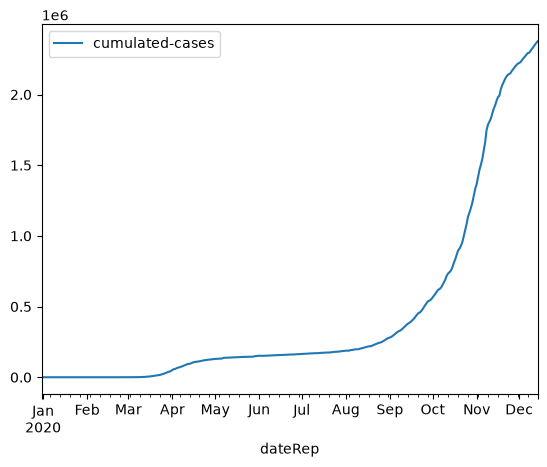

In [16]:
fr_data.plot(x="dateRep", y="cumulated-cases")

In [20]:
for i in range (totalrows - 2, -1, -1):
    fr_data.iloc[i, fr_data.columns.get_loc("growth-ratio")] = (
        fr_data.iloc[i, fr_data.columns.get_loc("newcases")]
        / fr_data.iloc[i + 1, fr_data.columns.get_loc("newcases")]
    )

/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/3160700574.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.iloc[i, fr_data.columns.get_loc("newcases")]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/3160700574.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.iloc[i, fr_data.columns.get_loc("newcases")]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/3160700574.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.iloc[i, fr_data.columns.get_loc("newcases")]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/3160700574.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.iloc[i, fr_data.columns.get_loc("newcases")]
/var/folders/z5/kyyhqxqd4b966377jmszys600000gn/T/ipykernel_20612/3160700574.py:3: RuntimeWarning: invalid value encountered in scalar divide
  fr_data.iloc[i, fr_data.columns.get_loc("newcases")]
/var/folders/z5/kyyh

In [22]:
fr_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,cumulated-cases,newcases,growth-ratio
0,2020-12-14,14,12,2020,11533,150,France,FR,FRA,67012883.0,Europe,236.326200,2376852,11533.0,0.826916
1,2020-12-13,13,12,2020,13947,194,France,FR,FRA,67012883.0,Europe,233.716254,2365319,13947.0,1.040355
2,2020-12-12,12,12,2020,13406,627,France,FR,FRA,67012883.0,Europe,231.556968,2351372,13406.0,0.974982
3,2020-12-11,11,12,2020,13750,292,France,FR,FRA,67012883.0,Europe,230.263187,2337966,13750.0,0.942103
4,2020-12-10,10,12,2020,14595,296,France,FR,FRA,67012883.0,Europe,229.984136,2324216,14595.0,1.064319


<Axes: xlabel='dateRep'>

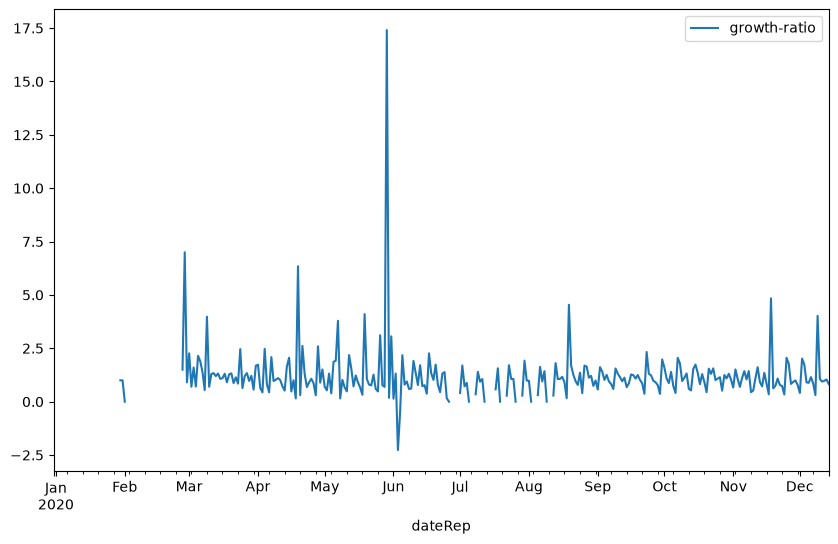

In [24]:
fr_data.plot(x="dateRep", y="growth-ratio", figsize=(10, 6))

<Axes: title={'center': 'Growth Ratio Over Time'}, xlabel='dateRep'>

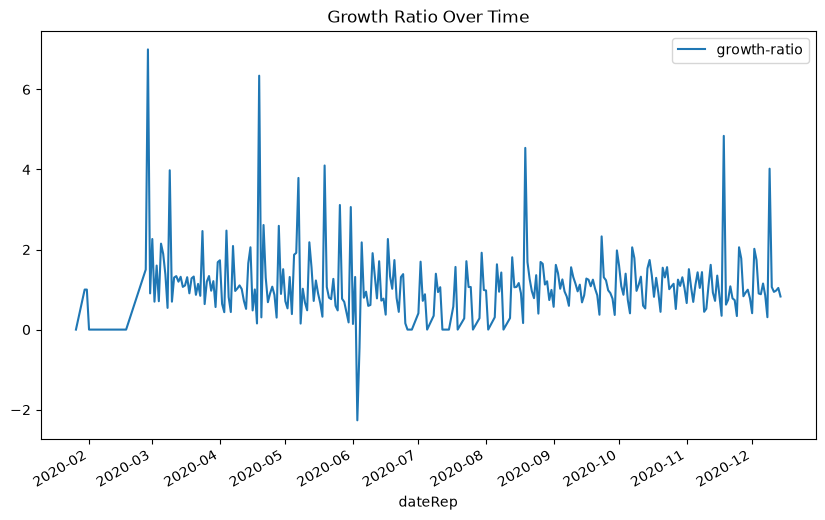

In [26]:
mask_bigvalueOff = fr_data["growth-ratio"] < 8
fr_data_filtered = fr_data[mask_bigvalueOff]
fr_data_filtered.plot(x="dateRep", y="growth-ratio", figsize=(10, 6), title="Growth Ratio Over Time")